
 ##### Задача предсказания наличие спама в сообщениях из электронной почты на основе содержащегося в них текста.
 ##### Используя  BERT и GPT для получения векторов 


**Датасет:**
##### Emails for spam or ham classification (Trec 2006)
https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fbayes2003%2Femails-for-spam-or-ham-classification-trec-2006

In [ ]:
#!pip install sentence_transformers

In [ ]:
#!pip install tf-keras

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import BertModel, BertTokenizer
from sentence_transformers import SentenceTransformer
from tensorflow.keras.layers import TextVectorization
from keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from torch.optim.lr_scheduler import StepLR

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
data_path = "email_origin.csv"
df = pd.read_csv(data_path, usecols=lambda column: column != 'id', nrows=1000)# берем первые 1000 строк без id
print(df.shape)
df.head()

(1000, 2)


,label,origin
0,0,Received: from rodan.UU.NET by aramis.rutgers....
1,1,Received: from unknown (HELO groucho.cs.psu.ed...
2,1,Received: \n\tfrom 24-151-178-89.dhcp.kgpt.tn....
3,0,Received: from psuvax1.cs.psu.edu ([130.203.2....
4,1,Received: from 201-1-198-159.dsl.telesp.net.br...


In [4]:
# Проверяем на наличие null-значений (при наличии удаляем...)
df.isnull().sum()

,0
label,0
origin,0


In [ ]:
# df = df.dropna()
# print(df.shape)
# df.head()

In [5]:
# проверяем наличие дубликатов
duplicates = df.duplicated()
print("duplicates:", duplicates.sum())

duplicates: 0


### Баланс классов

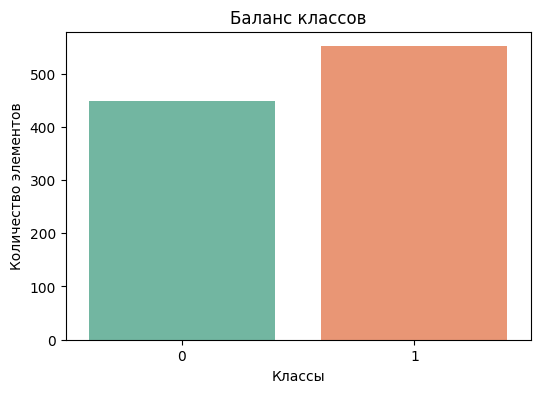

In [6]:
# смотрим баланс классов label(спам)
class_counts = df['label'].value_counts()

# Визуализация графика баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, hue='label', palette='Set2', legend=False)
plt.title('Баланс классов')
plt.xlabel('Классы')
plt.ylabel('Количество элементов')
plt.show()
# дисбаланс незначительный

### Предобработка данных

In [ ]:
# преобразуйте текст в нижний регистр+; преобразуйте сокращения+; удалите лишние пробелы+, знаки препинания+, стоп-слова+; лемматизируйте слова+

In [7]:
def text_cleaner(text):
    # Преобразование текста в нижний регистр
    text = text.lower()

    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text)

    # Преобразование сокращений
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'m", " am", text)

    # Удаление знаков препинания
    text = re.sub(r'[^\w\s]', '', text)

    # Удаление стоп-слов
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_text = [word for word in tokens if word.lower() not in stop_words]

    # Лемматизация слов
    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_text]

    # Объединение лемматизированных слов обратно в текст
    cleaned_text = ' '.join(lemmatized_text)

    return cleaned_text

СРАВНЕНИЕ ТЕКСТА ДО И ПОСЛЕ ОБРАБОТКИ

In [8]:
df['cleaner_text'] = df['origin'].map(lambda comments : text_cleaner(comments))

In [ ]:
#df[['origin', 'cleaner_text']]

In [9]:
df = df.drop(['origin'], axis=1)
print(df.shape)
df.head()

(1000, 2)


,label,cleaner_text
0,0,received rodanuunet aramisrutgersedu 559smi40r...
1,1,received unknown helo grouchocspsuedu 22213525...
2,1,received 2415117889dhcpkgpttnchartercom helo w...
3,0,received psuvax1cspsuedu 13020324 grouchocspsu...
4,1,received 2011198159dsltelespnetbr helo 32a3f2f...


# BERT

### Получение эмбеддингов с помощью BERT

In [122]:
# Загружаем предобученную модель BERT и токенизатор
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [123]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Перенос модели на устройство
bert_model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [124]:
encoded_captions = bert_tokenizer( df['cleaner_text'].tolist(), return_tensors='pt', padding=True, truncation=True)

In [16]:
from tqdm import tqdm

In [125]:
def embedding_imp(encoded_captions, pretrained_model, batch_size):
    '''
    Извлекает эмбеддинги предложений из предварительно обученной модели.
    Args:
      encoded_captions: токенизированные, закодированные данные.
      pretrained_model: предварительно обученная модель.
      batch_size: размер мини-батча.
    Return:
       all_sentence_embeddings: векторизованные данные.
    '''
    # Список для хранения embeddings
    all_sentence_embeddings = []

    # Разделим данные на батчи и передадим их в модель

    # for i in tqdm(range(0, len(encoded_captions['input_ids']), batch_size)):
    #     batch_input_ids = encoded_captions['input_ids'][i:i+batch_size]
    #     batch_attention_mask = encoded_captions['attention_mask'][i:i+batch_size]

    for i in tqdm(range(0, len(encoded_captions['input_ids']), batch_size)):
        batch_input_ids = encoded_captions['input_ids'][i:i+batch_size].to(device)
        batch_attention_mask = encoded_captions['attention_mask'][i:i+batch_size].to(device)

        # Передаем батчи в модель
        with torch.no_grad():
            batch_outputs = pretrained_model(batch_input_ids)

        # Извлекаем embeddings для каждого батча
        word_embeddings = batch_outputs.last_hidden_state

        # Mask для игнорирования padding tokens
        # Эмбеддинги слов умножаются на маску внимания, которая содержит информацию о том, какие токены являются
        # паддингом и должны быть проигнорированы. Умножение на маску помогает исключить влияние паддинг токенов на
        # вычисление окончательного представления предложения.
        masked_word_embeddings = word_embeddings * batch_attention_mask.unsqueeze(-1).float()

        # Объединение сумм с учётом токенов без non-padding
        # После умножения на маску каждый эмбеддинг слова суммируется по всем токенам в предложении. Это позволяет
        # объединить информацию из всех слов в предложении для создания его общего представления.
        sentence_embeddings = masked_word_embeddings.sum(dim=1)

        # Нормализация по количеству токенов без non-padding
        # Для нормализации полученного суммарного эмбеддинга предложения его значение делится на количество токенов
        # в предложении без паддинга. Это позволяет учесть разную длину предложений и обеспечить сравнимость эмбеддингов
        # различных предложений.
        sentence_embeddings /= batch_attention_mask.sum(dim=1, keepdim=True).float()

        # Добавляем embeddings батча в список
        all_sentence_embeddings.append(sentence_embeddings)

    # Собираем все embeddings батчей в один список
    all_sentence_embeddings = torch.cat(all_sentence_embeddings, dim=0)

    return all_sentence_embeddings

In [126]:
# Получение embeddings
bert_sentence_embeddings = embedding_imp(encoded_captions = encoded_captions, pretrained_model = bert_model, batch_size = 4)
#bert_sentence_embeddings = embedding_imp(encoded_captions, bert_model, batch_size=4)
print(bert_sentence_embeddings.shape)

100%|██████████| 250/250 [00:28<00:00,  8.89it/s]

torch.Size([1000, 768])


In [127]:
# Подготавливаем данные для обучения
y = df[['label']]
X_train, X_test, y_train, y_test = train_test_split(bert_sentence_embeddings, y, test_size=0.2, random_state=42)

In [128]:
# Преобразование данных в тензоры PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Создание DataLoader для обучающего и тестового наборов данных
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

<ipython-input-128-665e186764ef>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
<ipython-input-128-665e186764ef>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [148]:
# Определение модели
class ToxicityClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.9):
        super(ToxicityClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

In [150]:
# Параметры модели
input_size = bert_sentence_embeddings.shape[1]
hidden_size = 256
output_size = 1

In [151]:
# Создание модели
model = ToxicityClassifier(input_size, hidden_size, output_size)

In [152]:
# Определяем оптимизатор и функцию потерь
optimizer = optim.Adam(model.parameters())
# определение функции потерь
criterion = nn.BCELoss()

### Обучение модели

In [145]:
def train_validate_model(train_loader, test_loader, model, n_epochs, criterion, optimizer):
    # Пустые списки для хранения значений потерь и точности на обучающей и тестовой выборках
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()

            inputs = inputs.to(device)
            labels = labels.to(device).float()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            predicted_train = (outputs > 0.5).float()

            total_train += labels.size(0)

            correct_train += (predicted_train == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct_train / total_train)

         # Перевод модели в режим оценки
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).float()

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_loss += loss.item()

                predicted_test = (outputs > 0.5).float()

                total_test += labels.size(0)

                correct_test += (predicted_test == labels).sum().item()

        test_losses.append(test_loss / len(test_loader))
        test_accuracies.append(correct_test / total_test)

        print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, Test Accuracy: {test_accuracies[-1]:.4f}")

    return model, train_losses, test_losses, train_accuracies, test_accuracies

In [154]:
N_EPOCHS = 10

In [155]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ToxicityClassifier(
  (fc1): Linear(in_features=768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.9, inplace=False)
)

In [156]:
model, train_losses, test_losses, train_accuracies, test_accuracies = train_validate_model(train_loader, test_loader, model, N_EPOCHS, criterion, optimizer)

Epoch 1, Train Loss: 0.6027, Train Accuracy: 0.6512, Test Loss: 0.4334, Test Accuracy: 0.8500
Epoch 2, Train Loss: 0.4298, Train Accuracy: 0.8087, Test Loss: 0.2901, Test Accuracy: 0.8800
Epoch 3, Train Loss: 0.3565, Train Accuracy: 0.8438, Test Loss: 0.2336, Test Accuracy: 0.9150
Epoch 4, Train Loss: 0.2976, Train Accuracy: 0.8800, Test Loss: 0.1844, Test Accuracy: 0.9550
Epoch 5, Train Loss: 0.2658, Train Accuracy: 0.8950, Test Loss: 0.1605, Test Accuracy: 0.9550
Epoch 6, Train Loss: 0.2113, Train Accuracy: 0.9325, Test Loss: 0.1418, Test Accuracy: 0.9500
Epoch 7, Train Loss: 0.2195, Train Accuracy: 0.9137, Test Loss: 0.1263, Test Accuracy: 0.9600
Epoch 8, Train Loss: 0.1967, Train Accuracy: 0.9350, Test Loss: 0.1131, Test Accuracy: 0.9600
Epoch 9, Train Loss: 0.1725, Train Accuracy: 0.9463, Test Loss: 0.0989, Test Accuracy: 0.9650
Epoch 10, Train Loss: 0.1525, Train Accuracy: 0.9513, Test Loss: 0.0909, Test Accuracy: 0.9650


In [158]:
# Вычисляем метрики Accuracy и F1-score
y_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).cpu().numpy()

        outputs = model(inputs)
        preds = (outputs > 0.5).cpu().numpy().flatten()

        y_pred.extend(preds)
        y_true.extend(labels)

# Вычисление Accuracy и F1-score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1-score: {f1:.4f}")

Test Accuracy: 0.9650
Test F1-score: 0.9659


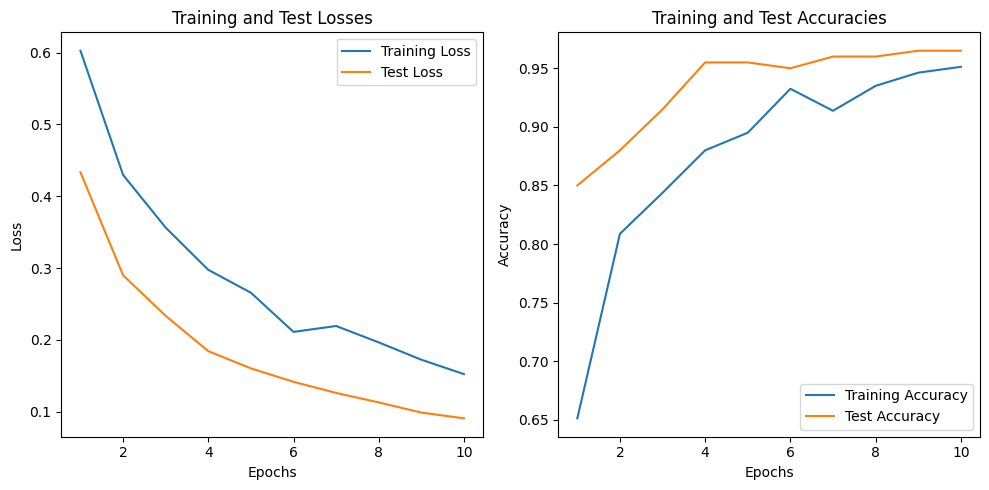

In [159]:
# Построение графиков
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), train_losses, label='Training Loss')
plt.plot(range(1, 11), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), train_accuracies, label='Training Accuracy')
plt.plot(range(1, 11), test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show()
# на графике Loss (потери при обучении) значения на валидационной выборке(Test Loss) уменьшаются так-же как и на обучающей,
# что говорит о качественном обучении.

In [164]:
# Получение вероятностей принадлежности каждому классу для тестового набора данных
probabilities = model(X_test_tensor).cpu()  # Копирование tensor на устройство CPU

In [165]:
# Переводим тензоры PyTorch обратно в массивы numpy
predictions = probabilities.detach().numpy()

In [166]:
class_names = ['label']

In [167]:
results = []

for i in range(len(X_test)):
    sentence = df['cleaner_text'][i]
    traits = []

    for j, class_name in enumerate(class_names):
        if predictions[i][j] >= 0.5:
            traits.append(class_name)

    result = {'Предложение': sentence, 'СПАМ': ', '.join(traits) if traits else 'Нет спама'}
    for k, class_name in enumerate(class_names):
        result[class_name] = "{:.8f}".format(predictions[i][k])
    results.append(result)

In [168]:
# снова строим датафрейм чтобы визуально оценить решение задачи
df_results = pd.DataFrame(results)
df_results

,Предложение,СПАМ,label
0,received rodanuunet aramisrutgersedu 559smi40r...,label,0.97979581
1,received unknown helo grouchocspsuedu 22213525...,label,0.97407746
2,received 2415117889dhcpkgpttnchartercom helo w...,Нет спама,0.05764114
3,received psuvax1cspsuedu 13020324 grouchocspsu...,label,0.97225934
4,received 2011198159dsltelespnetbr helo 32a3f2f...,Нет спама,0.03934123
...,...,...,...
195,received psuvax1csepsuedu 13020324 grouchocsep...,label,0.99053288
196,received host206230pool877interbusinessit helo...,Нет спама,0.00162796
197,received psuvax1csepsuedu 13020324 grouchocsep...,Нет спама,0.00085131
198,received unknown helo grouchocsepsuedua 222160...,Нет спама,0.01040068


# GPT-2

### Получение эмбеддингов с помощью GPT-2

In [172]:
from transformers import GPT2Tokenizer, GPT2Model

In [173]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [174]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
model = GPT2Model.from_pretrained('gpt2')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

In [175]:
# загружаем предварительно обученные параметры
model.to(device)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2SdpaAttention(
        (c_attn): Conv1D()
        (c_proj): Conv1D()
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D()
        (c_proj): Conv1D()
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [177]:
# применяем токенайзер Tokenize и pad sequences
encoded_captions = tokenizer(
    df['cleaner_text'].tolist(),
    return_tensors='pt',
    padding=True,
    truncation=True)

In [178]:
# encoded_captions переменная является словарем содержащем закодированные последовательности текста
# ключи к словарям соответствуют различным атрибутам напр.  input_ids и attention_mask
encoded_captions = {key: value.to(device) for key, value in encoded_captions.items()}

In [179]:
# оставляем для работы атрибут input_ids
input_ids = encoded_captions['input_ids']

In [180]:
# устанавливаем размер
batch_size = 4

In [181]:
# Инициализируем список для хранения embeddings
all_sentence_embeddings = []

# Разделим данные на батчи и передадим их в модель
for i in range(0, len(encoded_captions['input_ids']), batch_size):
    batch_input_ids = encoded_captions['input_ids'][i:i+batch_size].to(device)
    batch_attention_mask = encoded_captions['attention_mask'][i:i+batch_size].to(device)

    # Передаем батчи в модель
    with torch.no_grad():
        batch_outputs = model(batch_input_ids)

    # Извлекаем embeddings для каждого батча
    word_embeddings = batch_outputs.last_hidden_state

    # Mask для игнорирования padding tokens
    masked_word_embeddings = word_embeddings * batch_attention_mask.unsqueeze(-1).float()

    # Объединение сумм с учётом токенов без non-padding
    sentence_embeddings = masked_word_embeddings.sum(dim=1)

    # Нормализация по количеству токенов без non-padding
    sentence_embeddings /= batch_attention_mask.sum(dim=1, keepdim=True).float()

    # Добавляем embeddings батча в список
    all_sentence_embeddings.append(sentence_embeddings)

# Собираем все embeddings батчей в один список
all_sentence_embeddings = torch.cat(all_sentence_embeddings, dim=0)

In [182]:
all_sentence_embeddings

tensor([[ 1.1808e-01, -1.8499e-02, -3.5882e-01,  ..., -2.3292e-01,
          2.0055e-01,  2.6949e-01],
        [ 3.4172e-01,  5.1229e-04, -1.7955e-01,  ..., -8.4842e-02,
          2.1723e-01,  1.7723e-01],
        [ 2.8650e-01,  8.2238e-02, -1.1872e-01,  ..., -4.9336e-02,
          2.6646e-01,  7.9769e-02],
        ...,
        [ 2.5367e-01,  7.5734e-02, -4.8301e-01,  ..., -3.0117e-01,
          1.0133e-01,  6.6630e-02],
        [ 1.3363e-01, -6.8717e-02, -3.6952e-01,  ...,  4.5650e-02,
          2.9278e-01,  1.9194e-01],
        [ 1.5411e-01, -5.7111e-02, -5.4443e-01,  ...,  1.6240e-02,
          2.4742e-01,  9.9065e-02]], device='cuda:0')

### Обучение модели


In [183]:
y = df[['label']]

In [184]:
X_train, X_test, y_train, y_test = train_test_split(all_sentence_embeddings, y, test_size=0.2, random_state=42)

In [185]:
# Преобразование данных в тензоры PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Создание DataLoader для обучающего и тестового наборов данных
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

<ipython-input-185-665e186764ef>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
<ipython-input-185-665e186764ef>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [186]:
# Определение модели
class ToxicityClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        super(ToxicityClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

In [193]:
# Параметры модели
input_size = sentence_embeddings.shape[1]
hidden_size = 256
output_size = 1

In [194]:
# Создание модели
model_elmo = ToxicityClassifier(input_size, hidden_size, output_size)

In [205]:
model_elmo = model_elmo.to(device)

In [207]:
# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()
optimizer = optim.Adam(model_elmo.parameters())

In [212]:
# Обучение модели
for epoch in range(10):
    model_elmo.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = inputs.to(device)  # Переносим данные на устройство GPU
        labels = labels.squeeze().to(device)  # Переносим метки на устройство GPU и удаляем лишнее измерение
        outputs = model_elmo(inputs)
        loss = criterion(outputs.view(-1), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Вычисление точности на обучающей выборке
        predicted_train = (outputs > 0.5).float()  # Используем порог 0.5 для бинарной классификации
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()

    # Сохранение значений потерь и точности на обучающей выборке
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Оценка модели на тестовой выборке
    model_elmo.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)  # Переносим данные на устройство GPU
            labels = labels.squeeze().to(device)  # Переносим метки на устройство GPU и удаляем лишнее измерение
            outputs = model_elmo(inputs)
            loss = criterion(outputs.view(-1), labels)
            test_loss += loss.item()

            # Вычисление точности на тестовой выборке
            predicted_test = (outputs > 0.5).float()  # Используем порог 0.5 для бинарной классификации
            total_test += labels.size(0)
            correct_test += (predicted_test == labels).sum().item()

    # Сохранение значений потерь и точности на тестовой выборке
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(correct_test / total_test)

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Test Loss: {test_losses[-1]}, Test Accuracy: {test_accuracies[-1]}")

Epoch 1, Train Loss: 0.6999736976623535, Train Accuracy: 15.38, Test Loss: 0.6909721067973545, Test Accuracy: 15.4
Epoch 2, Train Loss: 0.6893013143539428, Train Accuracy: 14.9, Test Loss: 0.6911025302750724, Test Accuracy: 15.4
Epoch 3, Train Loss: 0.6765817666053772, Train Accuracy: 14.6925, Test Loss: 0.6755911878177098, Test Accuracy: 15.4
Epoch 4, Train Loss: 0.6616952896118165, Train Accuracy: 15.445, Test Loss: 0.5792196903909955, Test Accuracy: 15.55
Epoch 5, Train Loss: 0.6265665960311889, Train Accuracy: 16.11, Test Loss: 0.5674285803522382, Test Accuracy: 15.56
Epoch 6, Train Loss: 0.5897368597984314, Train Accuracy: 16.01, Test Loss: 0.5519159351076398, Test Accuracy: 15.67
Epoch 7, Train Loss: 0.5577974832057953, Train Accuracy: 16.2325, Test Loss: 0.5472373962402344, Test Accuracy: 15.86
Epoch 8, Train Loss: 0.5401975226402282, Train Accuracy: 16.46, Test Loss: 0.5412913986614772, Test Accuracy: 15.86
Epoch 9, Train Loss: 0.5409733963012695, Train Accuracy: 16.5625, Test 

In [216]:
# Предсказание меток для тестовой выборки GPT-2
model_elmo.eval()
predictions = []
true_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().cpu().numpy()
        outputs = model_elmo(inputs)
        preds = (outputs > 0.5).cpu().numpy().flatten()
        predictions.extend(preds)
        true_labels.extend(labels)

# Расчет метрик accuracy и F1-score
accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9600
F1-score: 0.9583


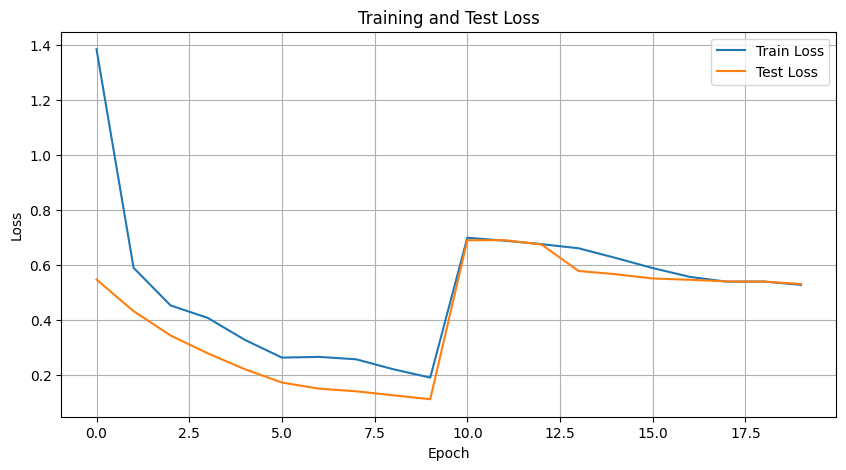

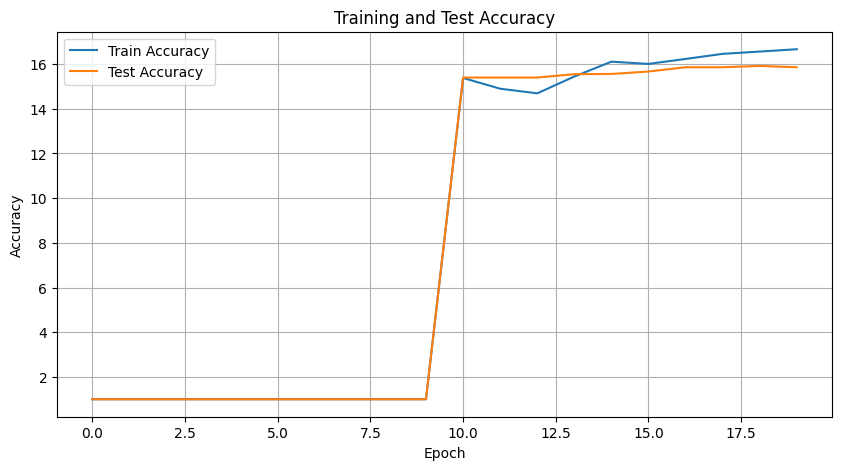

In [218]:
# Построение графика потерь на обучающей и тестовой выборках
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)
plt.show()

# Построение графика точности на обучающей и тестовой выборках
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()